In [31]:
# Importing Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [32]:
# Load Cleaned Datasets

users = pd.read_excel('/content/cleaned_users.xlsx')
txns = pd.read_excel('/content/cleaned_transactions.xlsx')

In [33]:
# Basic Data Checks

print("Users Shape:", users.shape)
print("Transactions Shape:", txns.shape)

# Check number of unique users
print("Unique Users:", users['user_id'].nunique())

# Verifying every transaction belongs to a valid user
print(
    "All transaction users present in users table:",
    txns['user_id'].isin(users['user_id']).all()
)

Users Shape: (6000, 8)
Transactions Shape: (28654, 7)
Unique Users: 6000
All transaction users present in users table: True


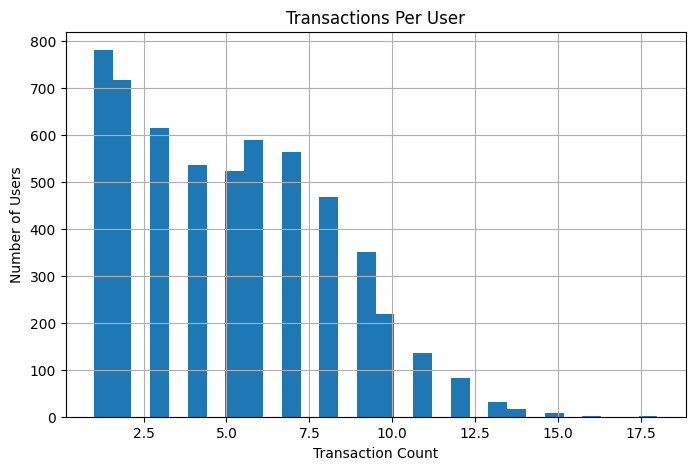

In [34]:
# EDA 1: Getting the distribution of Transactions Per User

txn_count_eda = (txns.groupby('user_id')['txn_id'].count())
plt.figure(figsize=(8,5))
txn_count_eda.hist(bins=30)
plt.title("Transactions Per User")
plt.xlabel("Transaction Count")
plt.ylabel("Number of Users")
plt.show()

In [35]:
# EDA 2: Spend Per User

spend_per_user = (txns.groupby('user_id')['order_value'].sum())
print(spend_per_user.describe())

count     5639.000000
mean      6919.765943
std       5495.909009
min     -14367.990000
25%       2638.395000
50%       5972.430000
75%       9954.755000
max      57311.080000
Name: order_value, dtype: float64


In [36]:
# Users with negative net spend
# Indicates heavy returns/refunds

print("Users with negative lifetime spend:",(spend_per_user < 0).sum())

Users with negative lifetime spend: 148


In [37]:
# EDA 3: Revenue Concentration

total_revenue = spend_per_user.sum()

top_10_percent_users = int(
    len(spend_per_user) * 0.10
)

top_revenue = (
    spend_per_user
    .sort_values(ascending=False)
    .head(top_10_percent_users)
    .sum()
)

print(
    "Revenue contribution by top 10% users:",
    round(top_revenue/total_revenue*100,2),
    "%"
)

Revenue contribution by top 10% users: 26.58 %


In [38]:
# --- EDA 4: Activation Funnel ------------------------------------------------
# Business question: Where do users drop off between signup and loyal customer?
# Stages: signup → first txn → repeat txn → confirmed cashback
total_signups       = len(users)
users_with_any_txn  = txns['user_id'].nunique()
repeat_users        = (txns.groupby('user_id').size() >= 2).sum()
confirmed_cashback  = txns[txns['cashback_status'] == 'confirmed']['user_id'].nunique()

print("\n── Activation Funnel ──")
print(f"  Signed up           : {total_signups}")
print(f"  Made 1+ transaction : {users_with_any_txn} ({users_with_any_txn/total_signups*100:.1f}%)")
print(f"  Made 2+ transactions: {repeat_users} ({repeat_users/total_signups*100:.1f}%)")
print(f"  Confirmed cashback  : {confirmed_cashback} ({confirmed_cashback/total_signups*100:.1f}%)")


── Activation Funnel ──
  Signed up           : 6000
  Made 1+ transaction : 5639 (94.0%)
  Made 2+ transactions: 4858 (81.0%)
  Confirmed cashback  : 5212 (86.9%)


In [39]:
# Define Churn
# Filter to users with enough history (signed up <= 2026-02-01)
snapshot_date = pd.Timestamp("2026-06-01")
eligible_users = users[users['signup_date'] <= '2026-02-01'].copy()

In [40]:
# Create Churn Label
# Churn window = last 90 days before snapshot (2026-03-03 to 2026-06-01)
window_start = pd.Timestamp("2026-03-03")
label_txns = txns[txns['txn_date'] >= window_start]
active_users = label_txns['user_id'].unique()
# Label — 1 if no activity in churn window, 0 if active
eligible_users['churn'] = (~eligible_users['user_id'].isin(active_users)).astype(int)
print(eligible_users['churn'].value_counts(normalize=True))

churn
0    0.505647
1    0.494353
Name: proportion, dtype: float64


In [41]:
# Feature Window
# Use only historical information
# to avoid data leakage

feature_txns = txns[txns['txn_date'] < '2026-03-03'].copy()
feature_snapshot = pd.Timestamp("2026-03-02")

In [42]:
# How many total purchases did the user make? (engagement depth)
txn_count = (feature_txns.groupby('user_id')['txn_id'].count().reset_index(name='txn_count'))

In [43]:
# Lifetime spend — a proxy for engagement value
total_spend = (feature_txns.groupby('user_id')['order_value'].sum().reset_index(name='total_spend'))

In [44]:
# Average basket size — distinguishes occasional big spenders from frequent small ones
avg_order_value = (feature_txns.groupby('user_id')['order_value'].mean().reset_index(name='avg_order_value'))

In [45]:
# Recency days since last transaction
last_txn = (feature_txns.groupby('user_id')['txn_date'].max().reset_index(name='last_txn_date'))
last_txn['days_since_last_txn'] = (feature_snapshot -last_txn['last_txn_date']).dt.days

In [46]:
customer_age = (
    eligible_users[
        ['user_id','signup_date']
    ].copy()
)

customer_age['customer_age_days'] = (
    feature_snapshot -
    customer_age['signup_date']
).dt.days

In [47]:
# how many different retailers did they visit?
unique_retailers = (
    feature_txns
    .groupby('user_id')['retailer']
    .nunique()
    .reset_index(name='unique_retailers')
)

In [48]:
# total cashback earned users who earned more cashback have more reason to stay
total_cashback = (
    feature_txns
    .groupby('user_id')['cashback_earned']
    .sum()
    .reset_index(name='total_cashback')
)

In [49]:
# return rate
return_count = (
    feature_txns[
        feature_txns['order_value'] < 0
    ]
    .groupby('user_id')
    .size()
    .reset_index(name='return_count')
)

return_rate = txn_count.merge(
    return_count,
    on='user_id',
    how='left'
)

return_rate['return_count'] = (
    return_rate['return_count']
    .fillna(0)
)

return_rate['return_rate'] = (
    return_rate['return_count']
    /
    return_rate['txn_count']
)

return_rate = return_rate[
    ['user_id','return_rate']
]

In [50]:
# recent activity transactions in the 30 days before the feature snapshot
last_30_txns = feature_txns[
    feature_txns['txn_date']
    >= '2026-02-01'
]

txn_last_30d = (
    last_30_txns
    .groupby('user_id')
    .size()
    .reset_index(name='txn_last_30d')
)

In [51]:
# Confirmed cashback rate — if most of a user's cashback is still pending/rejected,
# they may feel the platform isn't delivering value
confirmed_txns = (
    feature_txns[
        feature_txns['cashback_status']
        == 'confirmed'
    ]
    .groupby('user_id')
    .size()
    .reset_index(
        name='confirmed_txn_count'
    )
)

confirmed_cashback_rate = (
    txn_count.merge(
        confirmed_txns,
        on='user_id',
        how='left'
    )
)

confirmed_cashback_rate[
    'confirmed_txn_count'
] = (
    confirmed_cashback_rate[
        'confirmed_txn_count'
    ].fillna(0)
)

confirmed_cashback_rate[
    'confirmed_cashback_rate'
] = (
    confirmed_cashback_rate[
        'confirmed_txn_count'
    ]
    /
    confirmed_cashback_rate[
        'txn_count'
    ]
)

confirmed_cashback_rate = (
    confirmed_cashback_rate[
        [
            'user_id',
            'confirmed_cashback_rate'
        ]
    ]
)

In [52]:
# Assembling model dataframe
# Start from the eligible_users table (which carries the churn label and demographic features), then left-join all the transaction aggregations.
model_df = eligible_users.copy()

In [53]:
model_df = model_df.merge(txn_count,on='user_id',how='left')

model_df = model_df.merge(total_spend,on='user_id',how='left')

model_df = model_df.merge(avg_order_value,on='user_id',how='left')

model_df = model_df.merge(
    last_txn[['user_id','days_since_last_txn']],
    on='user_id',
    how='left'
)

model_df = model_df.merge(
    customer_age[['user_id','customer_age_days']],
    on='user_id',
    how='left'
)

model_df = model_df.merge(
    unique_retailers,
    on='user_id',
    how='left'
)

model_df = model_df.merge(
    total_cashback,
    on='user_id',
    how='left'
)

model_df = model_df.merge(
    return_rate,
    on='user_id',
    how='left'
)

model_df = model_df.merge(
    txn_last_30d,
    on='user_id',
    how='left'
)

model_df = model_df.merge(
    confirmed_cashback_rate,
    on='user_id',
    how='left'
)

In [54]:
# Fill missing values for users
# having no transaction history

transaction_features = [
    'txn_count',
    'total_spend',
    'avg_order_value',
    'days_since_last_txn',
    'unique_retailers',
    'total_cashback',
    'return_rate',
    'txn_last_30d',
    'confirmed_cashback_rate'
]

model_df[
    transaction_features
] = (
    model_df[
        transaction_features
    ].fillna(0)
)

In [55]:
# separate labels and features
y = model_df['churn']

X = model_df.drop(columns=['user_id','signup_date','churn'])

In [56]:
X

,signup_channel,city,age,gender,platform,referral_count,txn_count,total_spend,avg_order_value,days_since_last_txn,customer_age_days,unique_retailers,total_cashback,return_rate,txn_last_30d,confirmed_cashback_rate
0,social,Kolkata,22,female,app,0,1.0,1415.34,1415.340000,64.0,130,1.0,84.30,0.0,0.0,1.000000
1,paid_search,Delhi,27,female,app,0,2.0,168.83,84.415000,164.0,251,2.0,31.17,0.5,0.0,0.500000
2,paid_search,Pune,34,male,app,0,3.0,2851.45,950.483333,189.0,422,3.0,89.25,0.0,0.0,0.666667
3,social,Hyderabad,18,male,web,0,3.0,2154.20,718.066667,16.0,33,3.0,140.11,0.0,2.0,0.333333
4,paid_search,Bengaluru,18,female,app,0,0.0,0.00,0.000000,0.0,121,0.0,0.00,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4953,organic,Bengaluru,31,male,web,0,5.0,13535.01,2707.002000,19.0,177,5.0,787.37,0.0,2.0,0.600000
4954,affiliate,Bengaluru,27,male,app,0,1.0,1224.47,1224.470000,91.0,243,1.0,54.83,0.0,0.0,0.000000
4955,paid_search,Bengaluru,20,female,app,0,2.0,2795.42,1397.710000,122.0,202,2.0,63.28,0.0,0.0,0.000000
4956,paid_search,Delhi,30,male,app,0,1.0,6145.68,6145.680000,4.0,49,1.0,146.80,0.0,1.0,1.000000


In [60]:
# one hot encoding the features
X = pd.get_dummies(
    X,
    columns=[
        'signup_channel',
        'city',
        'gender',
        'platform'
    ],
    drop_first=True
)

In [61]:
# train test split
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
)

In [62]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [63]:
y_pred = lr.predict(X_test)

y_prob = lr.predict_proba(X_test)[:, 1]
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.7600806451612904
Precision: 0.750996015936255
Recall   : 0.7693877551020408
F1 Score : 0.7600806451612904
ROC AUC  : 0.8134604439385316

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.75      0.76       502
           1       0.75      0.77      0.76       490

    accuracy                           0.76       992
   macro avg       0.76      0.76      0.76       992
weighted avg       0.76      0.76      0.76       992



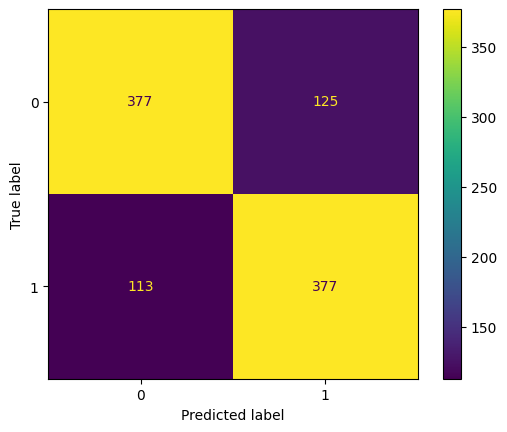

In [64]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [65]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.7752016129032258
Precision: 0.7986577181208053
Recall   : 0.7285714285714285
F1 Score : 0.7620064034151548
ROC AUC  : 0.8335189852833564


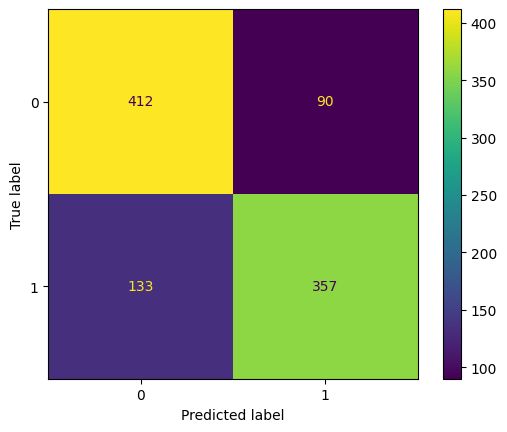

In [66]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.show()

In [67]:
# defining parameter grid
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [68]:
# running grid searh
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 8, 12, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='roc_auc', verbose=2)

In [69]:
# viewing best parameters
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest ROC-AUC:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 12, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}

Best ROC-AUC:
0.8574579221572698


In [70]:
# training final model
best_rf = grid_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)

y_prob_rf = best_rf.predict_proba(X_test)[:,1]

In [71]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.7741935483870968
Precision: 0.796875
Recall   : 0.7285714285714285
F1 Score : 0.7611940298507462
ROC AUC  : 0.836702170908204


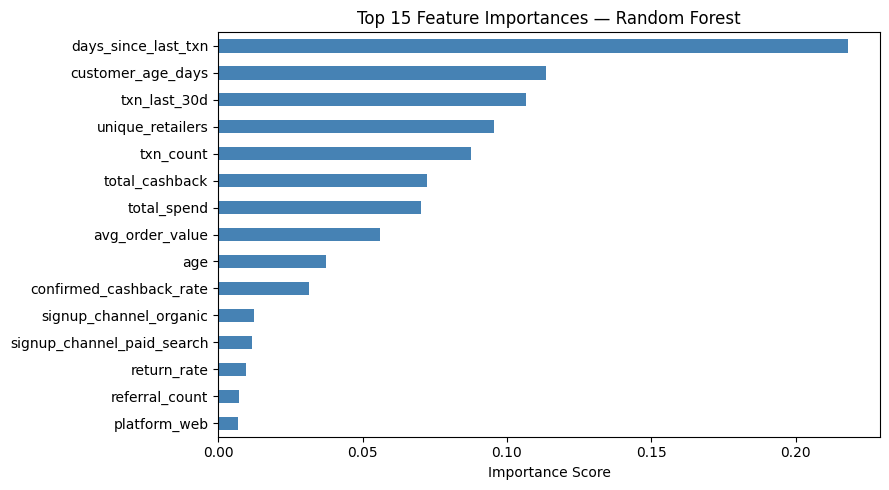

In [72]:
# Feature importance
importances = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [73]:
# Saving the model
import pickle

with open('churn_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

print("\nModel saved to churn_model.pkl")


Model saved to churn_model.pkl


In [77]:
# Churn Probability Score
churn_scores = pd.DataFrame({
    'user_id':   model_df['user_id'].values,
    'churn_prob': best_rf.predict_proba(X)[:, 1]
}).sort_values('churn_prob', ascending=False)

print("\nTop 10 highest-risk users:")
print(churn_scores.head(10))

# High-risk threshold = 0.65 (business decision — can be tuned based on
high_risk = churn_scores[churn_scores['churn_prob'] >= 0.65]
print(f"\nUsers flagged as high-risk (prob >= 0.65): {len(high_risk)}")


Top 10 highest-risk users:
      user_id  churn_prob
327      1397    0.994481
4497     6436    0.993771
3169     4855    0.993572
3475     5223    0.993392
180      1211    0.993081
1539     2872    0.992396
3308     5024    0.991941
2060     3502    0.991229
1231     2499    0.990870
3185     4875    0.990836

Users flagged as high-risk (prob >= 0.65): 1825
